In [163]:
from sklearn.datasets import fetch_openml
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.model_selection import cross_val_score
from sklearn.base import BaseEstimator
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from scipy.ndimage import shift

In [2]:
# 1. Download Dataset
mnist = fetch_openml("mnist_784", version=1)

In [3]:
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [4]:
# 2. Look At The Arrays
X, y = mnist ["data"], mnist["target"]

In [5]:
X.shape

(70000, 784)

In [6]:
y.shape

(70000,)

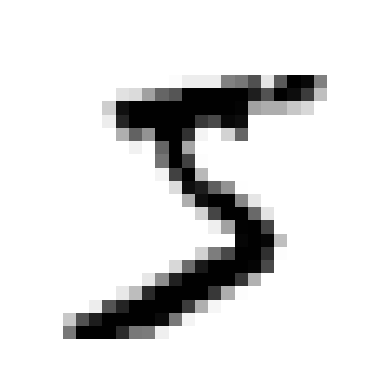

In [11]:
# 3. One Digit From The Dataset
some_digit = X.iloc[0].values
some_digit_image = some_digit.reshape(28, 28)

plt.imshow(some_digit_image, cmap="binary")
plt.axis("off")
plt.show()

In [12]:
# 4 What The Label Tells
y[0]


'5'

In [15]:
# 5. Cast y To Integer
y = y.astype(np.uint8)

In [16]:
# 6. Create Test Set And Training Set
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [22]:
# 7. Create The Target Vectors For This Classification Task
y_train_5 = (y_train == 5) # True For All 5s, False For All Other Digits
y_test_5 = (y_test == 5)

#8. Convert To Numpy
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()

In [23]:
# 9. Create SGDClassifier And Train It On The Whole Training Set
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [24]:
# 10. Detect Images Of The Number 5
sgd_clf.predict([some_digit])

array([ True])

In [30]:
# Evaluate perfomance Measures
# 11. Measuring Accuracy Using Cross-Validation

skfolds = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))
    
    
    



0.9669
0.91625
0.96785


In [32]:
# 12. Calculate Cross Vall Score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")


array([0.95035, 0.96035, 0.9604 ])

In [35]:
# 13. Dumb Classifier

class NeverClassifier(BaseEstimator):
     def fit(self, X, y=None):
         return self
     def predict (self, X):
         return np.zeros((len(X), 1), dtype=bool)

In [37]:
# 14. Dumb Models Accuracy

never_5_clf = NeverClassifier()
cross_val_score(never_5_clf, X_train, y_train_5, cv=3, scoring="accuracy") 

array([0.91125, 0.90855, 0.90915])

In [39]:
# 15. K fold Cross Validation But Instead Of Returning The Evaluation Scores It Returns The Prediction Made In Each Fold

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [41]:
# 16. Confusion Matrix
confusion_matrix(y_train_5, y_train_pred)

array([[53892,   687],
       [ 1891,  3530]])

In [42]:
# 17. Pretend We reached Perfection 
y_train_perfect_predictions = y_train_5 # Pretend We Reached Perfection
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

In [46]:
# 18. Presicion & Recall Score
precision_score(y_train_5, y_train_pred) # == 4096 / (4096 + 1522)

0.8370879772350012

In [47]:
recall_score(y_train_5, y_train_pred) # == 4096 / (4096 + 1325)

0.6511713705958311

In [49]:
# 19. Compute f1_score
f1_score(y_train_5, y_train_pred)

0.7325171197343847

In [50]:
# 20. Decision Scores
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([2164.22030239])

In [54]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)

In [55]:
y_some_digit_pred

array([ True])

In [56]:
# 21. Raise The Treshold
threshold = 8000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

In [58]:
# 22. Get Scores Of All Instances In The Training Set Specyfying To Return Decision Scores Instead Of Predictions

y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,
                             method="decision_function")


In [69]:
# 23. Plot Precision & Recall

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g--", label="Recall")
    plt.axvline(x=0, color="red", linestyle="--") 
    plt.xlabel("Threshold")
    plt.ylabel("Ratio/Percentage")
    plt.legend(loc="center left")
    plt.grid(True)

  

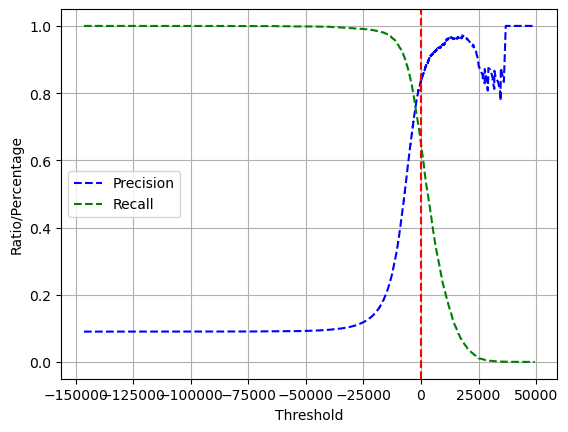

In [70]:
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.show()

In [71]:
# 24. Precision directly Againist Recall

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

def plot_precision_vs_recall(precisions, recalls):
    plt.plot(recalls, precisions, "b-", linewidth=2)
    plt.axvline(x=0, color="red", linestyle="--") 
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.grid(True)



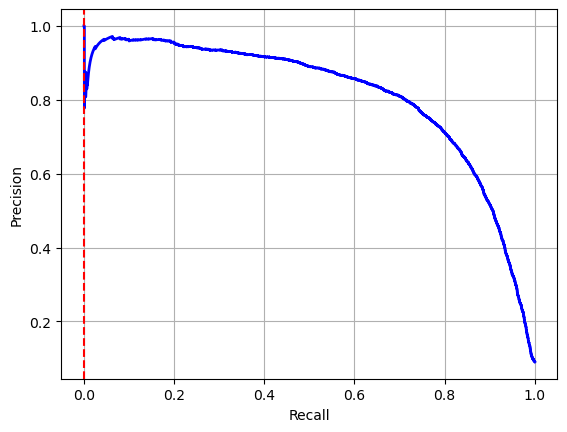

In [72]:
plot_precision_vs_recall(precisions, recalls)
plt.show()

In [73]:
# 25. Use np.argmax To Search For The Lowest threshold , Will Give You The first Index Of The Maximum Value Which In This Case Means The First Value

threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]

In [75]:
# 26. Make Predictions On The Training Set Instead Of Calling The Classifiers Predict Method()
y_train_pred_90 = (y_scores >= threshold_90_precision)

In [76]:
# 27. Check The Predictions Precision & Recall
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [77]:
recall_score(y_train_5, y_train_pred_90)

0.4799852425751706

In [79]:
# 28. To Plot The Roc Curve You Use the roc_curve() Function To Compute TPR And FPR For Various Threshold Values
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

In [80]:
# 29. Plot FPR Againist TPR Using Matplotlib
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], "k--") # Dashed diagonal
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.grid(True)


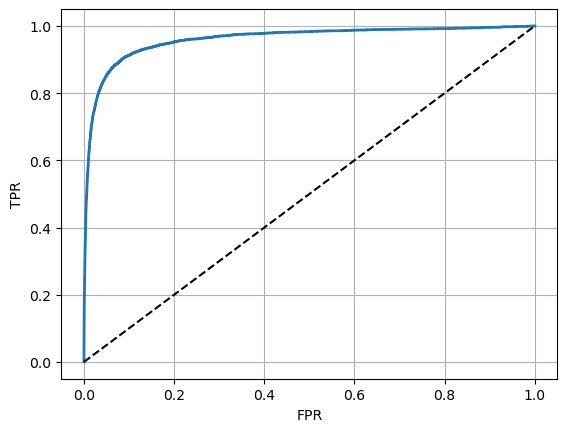

In [81]:
plot_roc_curve(fpr, tpr)
plt.show()

In [83]:
# 30. Compute The ROC AUC
roc_auc_score(y_train_5, y_scores)

0.9604938554008616

In [86]:
# 31. Training A RandomForestClassifier With K-Fold-Cross-Validation With A Parameter method="predict_proba"
forest_clf = RandomForestClassifier(random_state=42, n_jobs=-1)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3,
                                    method="predict_proba")


In [89]:
# 32. Use The Positive Class Probability As The Score

y_scores_forest = y_probas_forest[:, 1] # Score = proba of positive class
fpr_forest, tpr_forest, threshold_forest = roc_curve(y_train_5,y_scores_forest)

<function matplotlib.pyplot.show(close=None, block=None)>

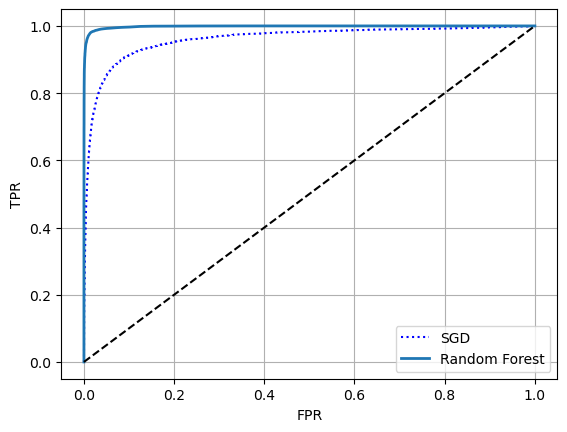

In [90]:
# 33. Plot The ROC curve
plt.plot(fpr, tpr, "b:", label="SGD")
plot_roc_curve(fpr_forest, tpr_forest, "Random Forest")
plt.legend(loc="lower right")
plt.show

In [91]:
# 34. ROC AUC score For RandomClassifier
roc_auc_score(y_train_5, y_scores_forest)

0.9983436731328145

In [93]:
 # 35. Convert The Possibilities In True/False
y_train_pred_forest = (y_scores_forest >= 0.5)


In [95]:
# 36. Check Precision And Recall Scores
precision_score(y_train_5, y_train_pred_forest)

0.9897468089558485

In [96]:
recall_score(y_train_5, y_train_pred_forest)

0.8725327430363402

In [98]:
# 37. Train And Predict Support Vector Machine Classifier
svm_clf = SVC()
svm_clf.fit(X_train, y_train) # y_train, not y_train_5
svm_clf.predict([some_digit])

array([5], dtype=uint8)

In [99]:
# 38. Decision Function To CHeck Scores
some_digit_scores = svm_clf.decision_function([some_digit])
some_digit_scores

array([[ 1.72501977,  2.72809088,  7.2510018 ,  8.3076379 , -0.31087254,
         9.3132482 ,  1.70975103,  2.76765202,  6.23049537,  4.84771048]])

In [102]:
# 39. Check If The High Score Is Indeed Coressponding To Class 5
np.argmax(some_digit_scores)


np.int64(5)

In [103]:
svm_clf.classes_

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [104]:
svm_clf.classes_[5]

np.uint8(5)

In [107]:
# 40. Create A Multiclass Classifier Using The OvR Strategy, Based On An SVC
ovr_clf = OneVsRestClassifier(SVC(), n_jobs=-1)
ovr_clf.fit(X_train, y_train)
ovr_clf.predict([some_digit])

array([5], dtype=uint8)

In [108]:
len(ovr_clf.estimators_)

10

In [109]:
# 41. Train A SGDClassifier
sgd_clf.fit(X_train, y_train)
sgd_clf.predict([some_digit])

array([3], dtype=uint8)

In [110]:
# 42. The Score That The SGD Classifier Assigned To Each Class
sgd_clf.decision_function([some_digit])

array([[-31893.03095419, -34419.69069632,  -9530.63950739,
          1823.73154031, -22320.14822878,  -1385.80478895,
        -26188.91070951, -16147.51323997,  -4604.35491274,
        -12050.767298  ]])

In [113]:
# 43. Use The cross_val_score() Function To Evaluate The SGDClassifier's Accuracy
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")

array([0.87365, 0.85835, 0.8689 ])

In [117]:
# 44. Increase Accuracy Above 89% By Scaling The Inputs And By False Prediction
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))
cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy", n_jobs=-1)

array([0.8983, 0.891 , 0.9018])

In [119]:
# 45. Confusion Matrix
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled[:20000], y_train[:20000], cv=3, n_jobs=-1)
conf_mx = confusion_matrix(y_train[:20000], y_train_pred)
conf_mx

array([[1895,    0,   12,    4,    3,   21,   14,    2,   43,    0],
       [   0, 2176,   20,    9,    2,   19,    2,    1,   47,    5],
       [  12,   13, 1693,   38,   24,   16,   24,   15,   91,    3],
       [  12,    9,   55, 1777,    1,   71,   15,   21,   86,   29],
       [   5,    4,   21,    5, 1754,    3,   13,    6,   59,   75],
       [  14,   12,   13,   67,   23, 1487,   23,    6,  103,   27],
       [  18,    7,   13,    2,   23,   23, 1844,    4,   36,    1],
       [   7,    4,   30,   13,   17,    2,    1, 1905,   18,   96],
       [  10,   27,   21,   42,    2,   43,   16,    5, 1727,   29],
       [  16,    8,   10,   29,   47,   16,    1,   60,   63, 1764]])

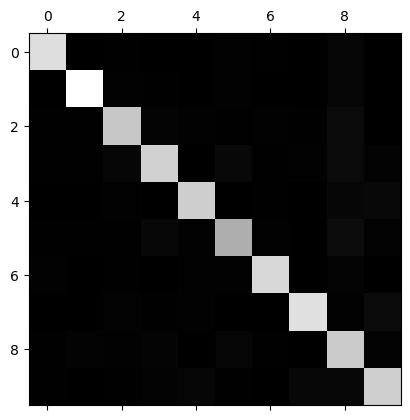

In [120]:
# 46. Image Represantion Of Confusing Matrix
plt.matshow(conf_mx, cmap=plt.cm.gray)
plt.show()

In [121]:
# 47. Divide Each Value In The Confusion Matrix By The Number Of Images In The Corresponding Class So That You Can Compare Error Rtes Instead Of Absolute Numbers Of Errors
row_sums = conf_mx.sum(axis=1, keepdims=True)
norm_conf_mx = conf_mx / row_sums

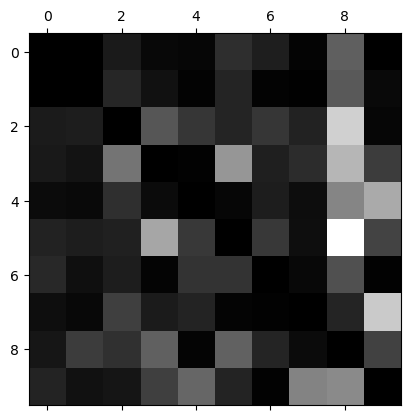

In [123]:
# 48. Fill The Diagonal With Zeros To Keep Only The Errors, And Plot The Result
np.fill_diagonal(norm_conf_mx, 0)
plt.matshow(norm_conf_mx, cmap=plt.cm.gray)
plt.show()


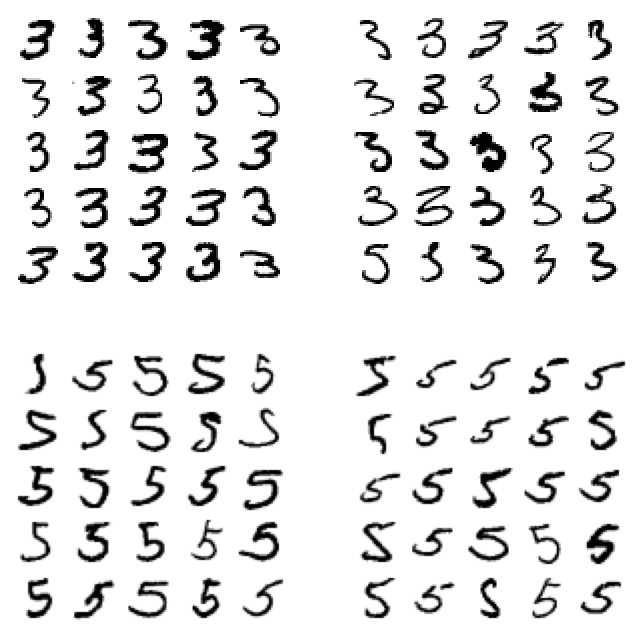

In [126]:
# 49. # Error Analysis: Visualizing 3s vs 5s Misclassifications

# 1. Define the helper function from the book's GitHub repository
def plot_digits(instances, images_per_row=10, **options):
    size = 28
    images_per_row = min(len(instances), images_per_row)
    
    # Convert to numpy array if it is a Pandas DataFrame/Series
    if hasattr(instances, "values"):
        instances = instances.values
        
    images = [instance.reshape(size, size) for instance in instances]
    n_rows = (len(instances) - 1) // images_per_row + 1
    row_images = []
    n_empty = n_rows * images_per_row - len(instances)
    images.append(np.zeros((size, size * n_empty)))
    
    for row in range(n_rows):
        rimages = images[row * images_per_row : (row + 1) * images_per_row]
        row_images.append(np.concatenate(rimages, axis=1))
        
    image = np.concatenate(row_images, axis=0)
    plt.imshow(image, cmap="binary", **options)
    plt.axis("off")





cl_a, cl_b = 3, 5
X_aa = X_train[:20000][(y_train[:20000] == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[:20000][(y_train[:20000] == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[:20000][(y_train[:20000] == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[:20000][(y_train[:20000] == cl_b) & (y_train_pred == cl_b)]

plt.figure(figsize=(8,8))
plt.subplot(221); plot_digits(X_aa[:25], images_per_row=5)
plt.subplot(222); plot_digits(X_ab[:25], images_per_row=5)
plt.subplot(223); plot_digits(X_ba[:25], images_per_row=5)
plt.subplot(224); plot_digits(X_bb[:25], images_per_row=5)
plt.show()

In [129]:
# 50. Multilabel Classification - KNeighborsClassifier - KneighborClassifier Fit
y_train_large = (y_train >=7)
y_train_odd = (y_train % 2 == 1)

y_multilabel = np.c_[y_train_large, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)



,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [130]:
# 51. Prediction
knn_clf.predict([some_digit])

array([[False,  True]])

In [132]:
# 52. Compute The Average f1 Score Across All labels
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)
f1_score(y_multilabel, y_train_knn_pred, average = "macro")

0.9764102655606048

In [134]:
# 53. Create A Training Set And Add More Noise To Their Pixel Intensities (MNIST Images)
noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise
noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise
y_train_mod = X_train
y_test_mod = X_test


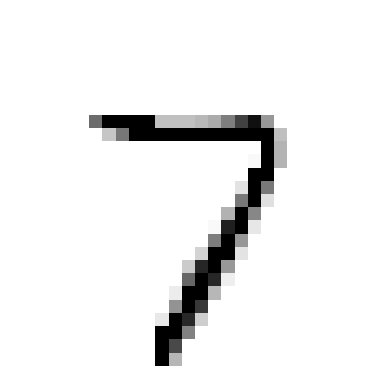

In [137]:
# 54. Clean The Image FiT And Predict 

# The Author's Original Function For Plotting A SINGLE Digit (plot_digit) And Not (plot_digits)

def plot_digit(data):
    image = data.reshape(28, 28)
    plt.imshow(image, cmap="binary", interpolation="nearest")
    plt.axis("off")


knn_clf.fit(X_train_mod, y_train_mod)
clean_digit = knn_clf.predict([X_test_mod[0]])
plot_digit(clean_digit)

In [143]:
# Exercice 1 - Achieve Over 97% Accuracy 
knn_clf =  KNeighborsClassifier(n_jobs=-1)
knn_clf.fit(X_train, y_train)
knn_clf.predict([some_digit])

array([5], dtype=uint8)

In [145]:
param_grid = [
   {"n_neighbors": [3 ,4, 5], "weights": ["uniform", "distance"]}
]

knn_clf = KNeighborsClassifier()

grid_search = GridSearchCV(knn_clf, param_grid, cv=3,
                           scoring="accuracy",
                           return_train_score=True, n_jobs=-1)

In [147]:
grid_search.fit(X_train_scaled[:20000], y_train[:20000])

,estimator,KNeighborsClassifier()
,param_grid,"[{'n_neighbors': [3, 4, ...], 'weights': ['uniform', 'distance']}]"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_neighbors,4


In [148]:
grid_search.best_params_

{'n_neighbors': 4, 'weights': 'distance'}

In [149]:
best_knn =  grid_search.best_estimator_

In [150]:
best_knn.fit(X_train_scaled, y_train)

,n_neighbors,4
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [151]:
X_test_scaled = scaler.transform(X_test.astype(float))

In [152]:
y_test_pred = best_knn.predict(X_test_scaled)

C:\Users\spiro\miniconda3\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


In [155]:
final_accuracy = accuracy_score(y_test, y_test_pred)

In [156]:
final_accuracy

0.9489

In [157]:
best_knn =  grid_search.best_estimator_

In [158]:
best_knn.fit(X_train_scaled, y_train)

,n_neighbors,4
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [ ]:
y_test_pred_full = best_knn.predict(X_test_scaled)

In [159]:
# Trying Wihout Standard Scaler

best_knn =  grid_search.best_estimator_


In [160]:
best_knn.fit(X_train, y_train)

,n_neighbors,4
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [161]:
y_test_pred_perfect = best_knn.predict(X_test)

In [162]:
accuracy_score(y_test, y_test_pred_perfect)

0.9714

In [164]:
# Exercice 2 Data Augmentation

# 1. WRITE THE SHIFT FUNCTION (As requested by the exercise)
def shift_image(image, dx, dy):
    # Reshape the flat 784 array to 28x28 matrix to shift it
    image_2d = image.reshape(28, 28)
    # dx is vertical shift (up/down), dy is horizontal shift (left/right)
    shifted_image_2d = shift(image_2d, [dy, dx], cval=0)
    # Flatten it back to 784 pixels
    return shifted_image_2d.reshape(-1)

# 2. SELECT A SUBSET FOR SPEED (We take 10,000 images instead of 60,000)
X_train_subset = X_train[:10000]
y_train_subset = y_train[:10000]

# 3. CREATE LIGTS (To store the augmented data)
X_train_augmented = [image for image in X_train_subset]
y_train_augmented = [label for label in y_train_subset]

# 4. DATA AUGMENTATION LOOP
# For each image, create 4 shifted copies and add them to the lists
for image, label in zip(X_train_subset, y_train_subset):
    for dx, dy in ((1, 0), (-1, 0), (0, 1), (0, -1)):
        X_train_augmented.append(shift_image(image, dx, dy))
        y_train_augmented.append(label)

# Convert lists back to NumPy arrays
X_train_augmented = np.array(X_train_augmented)
y_train_augmented = np.array(y_train_augmented)

print(f"Original subset size: {len(X_train_subset)}")
print(f"Augmented dataset size: {len(X_train_augmented)}") # Should be 50,000

# 5. TRAIN AND MEASURE ACCURACY WITH YOUR BEST KNN MODEL
best_knn = KNeighborsClassifier(n_neighbors=4, weights='distance', n_jobs=-1)
best_knn.fit(X_train_augmented, y_train_augmented)

# Predict on the original test set
y_pred = best_knn.predict(X_test)
print(f"Augmented Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
    

Original subset size: 10000
Augmented dataset size: 50000
Augmented Model Accuracy: 96.07%
